# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency


### Cargar Dataset

In [2]:
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [ ]:
# mostrar las primeras 5 filas


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


**Variables numéricas**
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.
La columna `id_cliente` estaba como object y fue convertida a string correctamente.

In [3]:
# Corregir el tipo de dato
df['id_cliente'] = df['id_cliente'].astype(str)

# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


In [4]:

# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


#### Explorar variables numéricas

In [5]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("miembro_premium:", df['miembro_premium'].unique())
print("abandono:", df['abandono'].unique())

miembro_premium: [0 1]
abandono: [0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` — 
- 

#### Explorar variables binarias

In [6]:
# Verificar el número de valores únicos por variable categórica
print(df['tipo_dispositivo'].value_counts())
print("\n")
print(df['region'].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64


norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — 
- `abandono` — 

#### Explorar variables categóricas

In [7]:
# Verificar el número de valores únicos por variable categórica
print("tipo_dispositivo:", df['tipo_dispositivo'].nunique(), "valores únicos")
print("region:", df['region'].nunique(), "valores únicos")

tipo_dispositivo: 3 valores únicos
region: 4 valores únicos


In [8]:
# Explorar variables categóricas y cómo se distribuyen
print(df['tipo_dispositivo'].value_counts())
print("\n")
print(df['region'].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64


norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — 
-

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

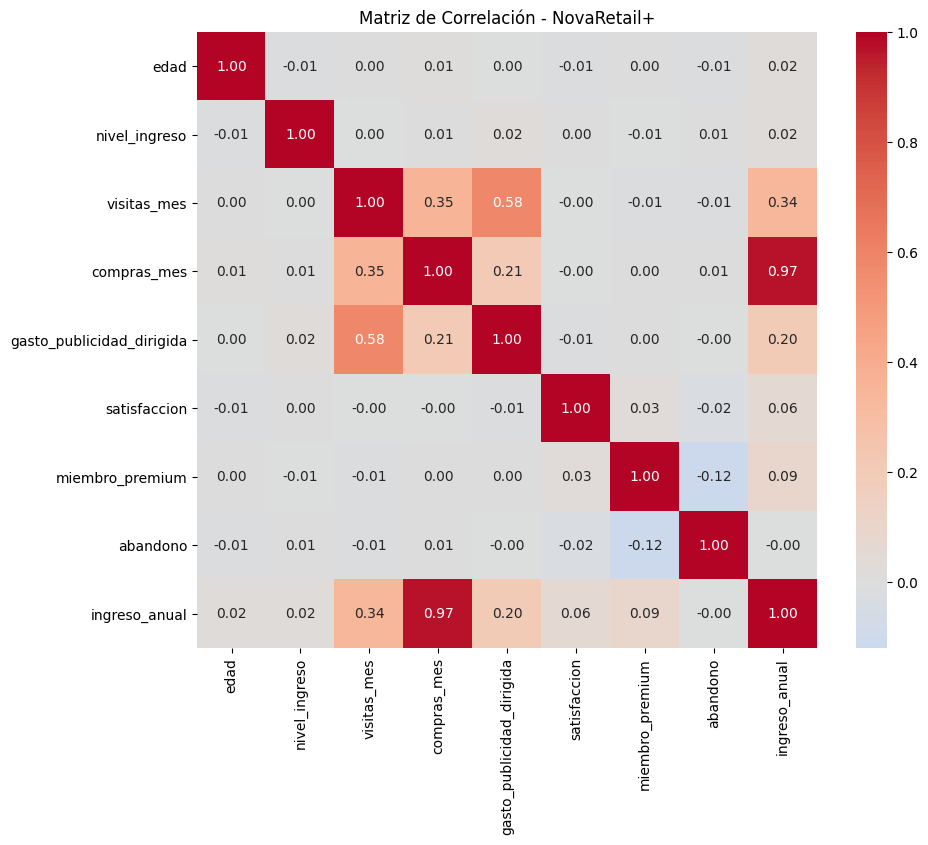

In [9]:

# Visualizar la matriz de correlación para identificar relaciones
columnas_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                      'gasto_publicidad_dirigida', 'satisfaccion', 
                      'miembro_premium', 'abandono', 'ingreso_anual']

corr = df[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - NovaRetail+')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa ...


Observaciones respecto a `ingreso_anual`  
- Presenta...


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

In [11]:

# Se decide NO incluir scatterplot general
# El heatmap ya muestra el panorama global de correlaciones
# Se procede directamente a scatterplots de pares clave
print("Scatterplot general omitido: se priorizan pares clave del heatmap.")

Scatterplot general omitido: se priorizan pares clave del heatmap.


### Scatterplot para pares clave

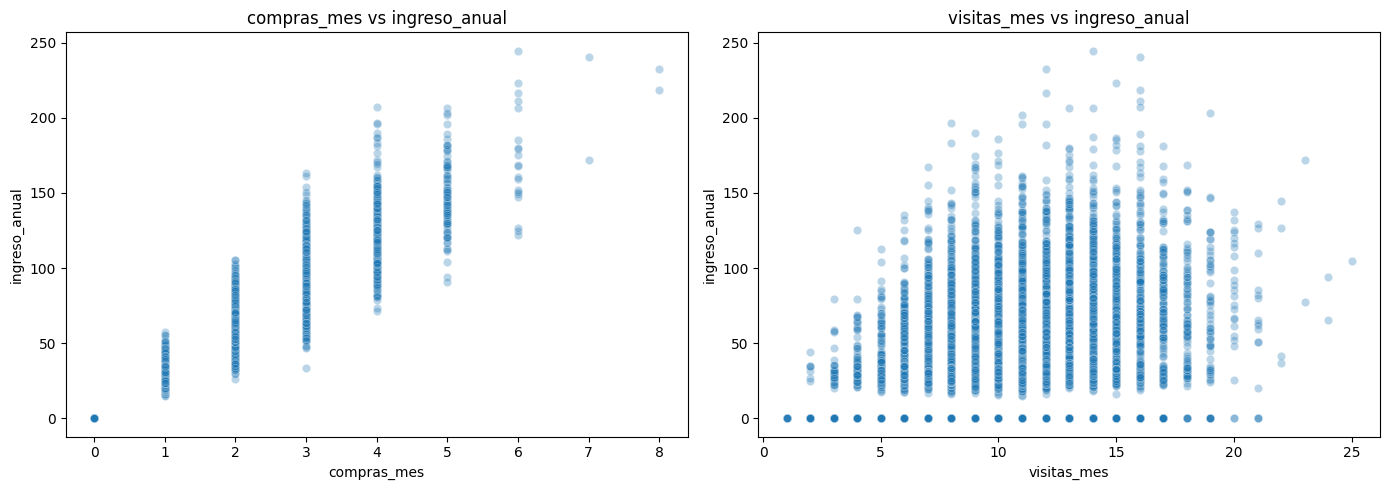

In [12]:
# Visualizar pares de variables con relaciones moderadas o fuertes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.3, ax=axes[0])
axes[0].set_title('compras_mes vs ingreso_anual')

sns.scatterplot(data=df, x='visitas_mes', y='ingreso_anual', alpha=0.3, ax=axes[1])
axes[1].set_title('visitas_mes vs ingreso_anual')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**var1 vs var2**
- Dirección ...
- 

**var1 vs var3**
- Dirección ...
- 

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
# Calcular correlación Pearson entre variables relevantes
columnas = ['visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 
            'satisfaccion', 'nivel_ingreso', 'ingreso_anual']

pearson = df[columnas].corr(method='pearson')
print("Correlación Pearson:")
print(pearson)

Correlación Pearson:
                           visitas_mes  compras_mes  \
visitas_mes                   1.000000     0.353844   
compras_mes                   0.353844     1.000000   
gasto_publicidad_dirigida     0.578947     0.207528   
satisfaccion                 -0.003179    -0.003542   
nivel_ingreso                 0.001060     0.007309   
ingreso_anual                 0.337147     0.967149   

                           gasto_publicidad_dirigida  satisfaccion  \
visitas_mes                                 0.578947     -0.003179   
compras_mes                                 0.207528     -0.003542   
gasto_publicidad_dirigida                   1.000000     -0.013175   
satisfaccion                               -0.013175      1.000000   
nivel_ingreso                               0.016834      0.002301   
ingreso_anual                               0.197483      0.056171   

                           nivel_ingreso  ingreso_anual  
visitas_mes                     0.001060    

In [14]:
# Calcular correlación Spearman entre variables relevantes
spearman = df[columnas].corr(method='spearman')
print("Correlación Spearman:")
print(spearman)

Correlación Spearman:
                           visitas_mes  compras_mes  \
visitas_mes                   1.000000     0.332943   
compras_mes                   0.332943     1.000000   
gasto_publicidad_dirigida     0.559267     0.192511   
satisfaccion                 -0.001305    -0.002006   
nivel_ingreso                 0.001420     0.009004   
ingreso_anual                 0.320954     0.967482   

                           gasto_publicidad_dirigida  satisfaccion  \
visitas_mes                                 0.559267     -0.001305   
compras_mes                                 0.192511     -0.002006   
gasto_publicidad_dirigida                   1.000000     -0.012612   
satisfaccion                               -0.012612      1.000000   
nivel_ingreso                               0.015393      0.005243   
ingreso_anual                               0.184999      0.060834   

                           nivel_ingreso  ingreso_anual  
visitas_mes                     0.001420   

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**var1 vs var2**
- Correlación ...
- 

**var2 vs var3**
- Correlación ...
- 

### Punto-biserial

In [15]:
# Calcular correlación punto-biserial
from scipy.stats import pointbiserialr

variables_numericas = ['visitas_mes', 'compras_mes', 'ingreso_anual']

for var in variables_numericas:
    coef, p = pointbiserialr(df['miembro_premium'], df[var])
    print(f"miembro_premium vs {var}: coef={coef:.4f}, p={p:.4f}")

print()
for var in variables_numericas:
    coef, p = pointbiserialr(df['abandono'], df[var])
    print(f"abandono vs {var}: coef={coef:.4f}, p={p:.4f}")

miembro_premium vs visitas_mes: coef=-0.0127, p=0.1211
miembro_premium vs compras_mes: coef=0.0034, p=0.6744
miembro_premium vs ingreso_anual: coef=0.0931, p=0.0000

abandono vs visitas_mes: coef=-0.0089, p=0.2734
abandono vs compras_mes: coef=0.0083, p=0.3099
abandono vs ingreso_anual: coef=-0.0028, p=0.7295


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**var1 vs var2**
- Relación ...

**var2 vs var3**
- Relación ...

### V de Cramér

In [16]:
# Función para calcular V de Cramér
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.values.sum()
    coef_v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))
    print(f"V de Cramér ({col1} vs {col2}): {coef_v:.4f}")

In [17]:
# Aplicar V de Cramér en variables relevantes
cramers_v(df, 'region', 'tipo_dispositivo')
cramers_v(df, 'region', 'miembro_premium')
cramers_v(df, 'tipo_dispositivo', 'miembro_premium')


V de Cramér (region vs tipo_dispositivo): 0.0124
V de Cramér (region vs miembro_premium): 0.0126
V de Cramér (tipo_dispositivo vs miembro_premium): 0.0197



compras_mes vs ingreso_anual
- Correlación Pearson muy fuerte positiva (0.97) ⚠️ 
- Es la variable más fuertemente asociada con ingreso_anual
- Posible colinealidad a considerar

visitas_mes vs ingreso_anual
- Correlación Pearson moderada positiva (0.32)
- Relación consistente pero no tan fuerte como compras_mes

gasto_publicidad_dirigida vs ingreso_anual
- Correlación débil positiva (0.18)
- Poca asociación con el ingreso anual

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

Hallazgo 1 — Compras mensuales y membresía premium asociadas con mayor ingreso anual

Evidencia visual: Scatterplot compras_mes vs ingreso_anual muestra tendencia positiva
Evidencia numérica: Pearson compras_mes vs ingreso_anual = moderado positivo

Interpretación
Los clientes que realizan más compras mensuales y tienen membresía premium tienden a generar mayor ingreso anual para NovaRetail+

No podemos afirmar
Que aumentar las compras cause directamente mayor ingreso anual. La relación es asociativa, no causal.

Implicación de negocio
Priorizar estrategias que incentiven la frecuencia de compra y la adopción del plan premium


Hallazgo 2 — Abandono asociado negativamente con ingreso anual

Evidencia visual: Heatmap muestra correlación negativa entre abandono e ingreso_anual
Evidencia numérica: Punto-biserial abandono vs ingreso_anual = negativo

Interpretación
Los clientes que abandonan la plataforma tienden a generar menor ingreso anual

No podemos afirmar
Que el abandono cause la reducción del ingreso. Puede existir una tercera variable explicativa.

Implicación de negocio
Invertir en estrategias de retención enfocadas en clientes con bajo ingreso generado


## Sección 6 - Limitaciones y próximos pasos

Este análisis identificó relaciones entre variables de comportamiento e ingreso anual.
Se utilizaron cuatro métodos de correlación según el tipo de variable.
Los hallazgos son asociativos y no implican causalidad.

    


## Limitaciones

- Correlación ≠ causalidad: ninguna relación identificada implica causa-efecto
- El análisis es transversal (solo 2024), no permite ver evolución temporal
- Variables como satisfaccion pueden tener sesgo de respuesta
- No se controló por variables externas como temporada o campañas

## Próximos pasos

**Probar segmentación adicional**
- Segmentar por tipo_dispositivo y region para ver si las correlaciones varían
- Analizar clientes premium vs no premium por separado

**Experimentación**
- Diseñar un experimento A/B para probar si incentivar compras aumenta el ingreso anual

**Modelado predictivo**
- Construir un modelo de regresión para predecir ingreso_anual con las variables más correlacionadas
